# Polymarket Daily BTC Price-Range Markets

This notebook analyses Polymarket's "Will the price of Bitcoin be between $X and $Y on date D?" markets.

For each resolution date the order book is sliced into mutually-exclusive $2k bands.
The Yes price of each band is the market-implied probability that BTC's closing price
will fall inside that band.

**Steps**

1. Combine the per-(date, band) parquet files into two consolidated tables: one for the
   minute-by-minute Yes price history, one for the aggregated trades.
2. Build a discrete market-implied distribution of BTC closing price at every minute and
   fit a lognormal to extract implied volatility as a function of time-to-resolution.
3. Heatmap of bands coloured by market price (probability).
4. Test market efficiency: compare the market-implied probabilities at 1 day / 12 h /
   4 h before resolution against the empirical hit rate (calibration / reliability plot).


In [2]:
import os
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import norm
from scipy.optimize import minimize

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

DATA_ROOT = Path("01 Data Extraction/Data")
RAW_DIRS = [
    DATA_ROOT / "BTC Reach Daily 20251101_20260501",
]
COMBINED_DIR = DATA_ROOT / "BTC Reach Daily Combined"
COMBINED_DIR.mkdir(parents=True, exist_ok=True)
PRICES_PARQUET = COMBINED_DIR / "prices.parquet"
TRADES_PARQUET = COMBINED_DIR / "trades.parquet"
SUMMARY_PARQUET = COMBINED_DIR / "market_summary.parquet"

print("Raw folders:", [str(p) for p in RAW_DIRS])
print("Combined output:", COMBINED_DIR)


Raw folders: ['01 Data Extraction/Data/BTC Reach Daily 20251101_20260501']
Combined output: 01 Data Extraction/Data/BTC Reach Daily Combined


## 1. Combine raw parquet files

The raw folder stores one `Price YYYYMMDD <band>.parquet` and one
`Trade YYYYMMDD <band>.parquet` per market.  We concatenate them into two large
parquet files, keeping only the columns that are useful downstream.  The combined
files are cached so the cell is cheap after the first run.


In [3]:
PRICE_KEEP = [
    "target_date", "price_band_label", "lower_price", "upper_price", "band_width",
    "event_slug", "market_slug", "condition_id", "market_id",
    "market_start_date", "market_end_date", "closed_time",
    "outcome_index", "outcome_label", "outcome_price", "token_id",
    "timestamp", "price",
]
TRADE_KEEP = [
    "target_date", "price_band_label", "lower_price", "upper_price", "band_width",
    "event_slug", "market_slug", "condition_id", "market_id",
    "market_start_date", "market_end_date", "closed_time",
    "outcome_index", "outcome_label", "asset",
    "timestamp",
    "trade_count", "volume_shares", "volume_usdc", "vwap",
    "buy_volume_shares", "sell_volume_shares",
    "buy_trade_count", "sell_trade_count",
    "last_trade_price",
    "cumulative_trade_count", "cumulative_volume_shares", "cumulative_volume_usdc",
]


def _combine(pattern: str, keep: list[str], out: Path) -> pd.DataFrame:
    files: list[str] = []
    for d in RAW_DIRS:
        files.extend(sorted(glob.glob(str(d / pattern))))
    print(f"  -> {len(files)} files matching {pattern}")
    frames = []
    for f in files:
        df = pd.read_parquet(f, columns=keep)
        frames.append(df)
    out_df = pd.concat(frames, ignore_index=True)
    out_df["target_date"] = pd.to_datetime(out_df["target_date"], utc=True)
    out_df.to_parquet(out, index=False)
    return out_df


if PRICES_PARQUET.exists() and TRADES_PARQUET.exists():
    print("Combined parquet files already exist, loading from cache.")
    prices = pd.read_parquet(PRICES_PARQUET)
    trades = pd.read_parquet(TRADES_PARQUET)
else:
    print("Combining Price* files...")
    prices = _combine("Price *.parquet", PRICE_KEEP, PRICES_PARQUET)
    print("Combining Trade* files...")
    trades = _combine("Trade *.parquet", TRADE_KEEP, TRADES_PARQUET)

# Market summary - one row per market
if SUMMARY_PARQUET.exists():
    summary = pd.read_parquet(SUMMARY_PARQUET)
else:
    summary_frames = []
    for d in RAW_DIRS:
        f = next(iter(d.glob("Market Summary *.parquet")), None)
        if f is not None:
            summary_frames.append(pd.read_parquet(f))
    summary = pd.concat(summary_frames, ignore_index=True)
    summary.to_parquet(SUMMARY_PARQUET, index=False)

print(f"\nprices : {prices.shape[0]:,} rows  x  {prices.shape[1]} cols")
print(f"trades : {trades.shape[0]:,} rows  x  {trades.shape[1]} cols")
print(f"summary: {summary.shape[0]:,} rows  x  {summary.shape[1]} cols")
prices.head(3)


Combined parquet files already exist, loading from cache.



prices : 2,096,640 rows  x  18 cols
trades : 2,096,640 rows  x  28 cols
summary: 700 rows  x  42 cols


,target_date,price_band_label,lower_price,upper_price,band_width,event_slug,market_slug,condition_id,market_id,market_start_date,market_end_date,closed_time,outcome_index,outcome_label,outcome_price,token_id,timestamp,price
0,2025-11-01 00:00:00+00:00,102k-104k,102000,104000,2000,bitcoin-price-on-november-1,will-the-price-of-bitcoin-be-between-102000-10...,0x425b4bbb95458d39dc0350e3db87eab83b765ca9d9cf...,649614,2025-10-25 16:09:42.692462+00:00,2025-11-01 16:00:00+00:00,2025-11-01 19:29:06+00:00,1,No,1,1093588996537549887944743268819589396026841921...,2025-10-31 16:00:00+00:00,0.9915
1,2025-11-01 00:00:00+00:00,102k-104k,102000,104000,2000,bitcoin-price-on-november-1,will-the-price-of-bitcoin-be-between-102000-10...,0x425b4bbb95458d39dc0350e3db87eab83b765ca9d9cf...,649614,2025-10-25 16:09:42.692462+00:00,2025-11-01 16:00:00+00:00,2025-11-01 19:29:06+00:00,1,No,1,1093588996537549887944743268819589396026841921...,2025-10-31 16:01:00+00:00,0.9915
2,2025-11-01 00:00:00+00:00,102k-104k,102000,104000,2000,bitcoin-price-on-november-1,will-the-price-of-bitcoin-be-between-102000-10...,0x425b4bbb95458d39dc0350e3db87eab83b765ca9d9cf...,649614,2025-10-25 16:09:42.692462+00:00,2025-11-01 16:00:00+00:00,2025-11-01 19:29:06+00:00,1,No,1,1093588996537549887944743268819589396026841921...,2025-10-31 16:02:00+00:00,0.9915


## 2. Build the Yes-price panel and identify the settled band

For each market the Yes outcome carries the market-implied probability that BTC closes
inside the band.  We pivot the data into a `(date, timestamp, band)` panel of Yes prices
and recover the settlement band as the one whose Yes outcome ultimately settled at 1.


In [4]:
# Yes-only minute-by-minute panel
yes = prices[prices["outcome_label"] == "Yes"].copy()
yes["band_mid"] = (yes["lower_price"] + yes["upper_price"]) / 2.0
yes["target_date"] = pd.to_datetime(yes["target_date"], utc=True).dt.normalize()
yes["timestamp"] = pd.to_datetime(yes["timestamp"], utc=True)
yes["minutes_to_resolution"] = (
    (yes["market_end_date"] - yes["timestamp"]).dt.total_seconds() / 60.0
)
print(f"Yes panel : {yes.shape[0]:,} rows")
print(f"Dates     : {yes['target_date'].nunique()}  "
      f"({yes['target_date'].min().date()} -> {yes['target_date'].max().date()})")
print(f"Bands/day : {yes.groupby('target_date')['price_band_label'].nunique().describe().round(2).to_dict()}")

# Settlement: the Yes outcome row whose final outcome_price == 1
settle = (yes.groupby(["target_date", "price_band_label"], as_index=False)
              .agg(lower_price=("lower_price", "first"),
                   upper_price=("upper_price", "first"),
                   band_mid=("band_mid", "first"),
                   outcome_price=("outcome_price", "last")))
winners = settle[settle["outcome_price"] == 1]
print(f"\nResolved days with a winning band: {winners['target_date'].nunique()}")

# Per-day settlement summary: which band won
settled_band = (winners.set_index("target_date")
                       [["price_band_label", "lower_price", "upper_price", "band_mid"]]
                       .rename(columns={"price_band_label": "settled_band",
                                        "lower_price": "settled_lower",
                                        "upper_price": "settled_upper",
                                        "band_mid": "settled_mid"}))
settled_band.head()


Yes panel : 1,048,320 rows
Dates     : 81  (2025-11-01 -> 2026-01-21)
Bands/day : {'count': 81.0, 'mean': 8.99, 'std': 0.11, 'min': 8.0, '25%': 9.0, '50%': 9.0, '75%': 9.0, 'max': 9.0}

Resolved days with a winning band: 71


,settled_band,settled_lower,settled_upper,settled_mid
target_date,,,,
2025-11-01 00:00:00+00:00,110k-112k,110000,112000,111000.0
2025-11-02 00:00:00+00:00,110k-112k,110000,112000,111000.0
2025-11-03 00:00:00+00:00,106k-108k,106000,108000,107000.0
2025-11-05 00:00:00+00:00,102k-104k,102000,104000,103000.0
2025-11-06 00:00:00+00:00,100k-102k,100000,102000,101000.0


## 3. Heatmap of bands coloured by Yes price

The colour of cell `(t, band)` is the market-implied probability that BTC closes inside
that band, where `t` is the time-to-resolution (in hours) and bands are stacked by their
lower price.  We plot four representative days and one aggregate view in which bands have
been re-centred on the eventually-realised band so cross-day averages are meaningful.


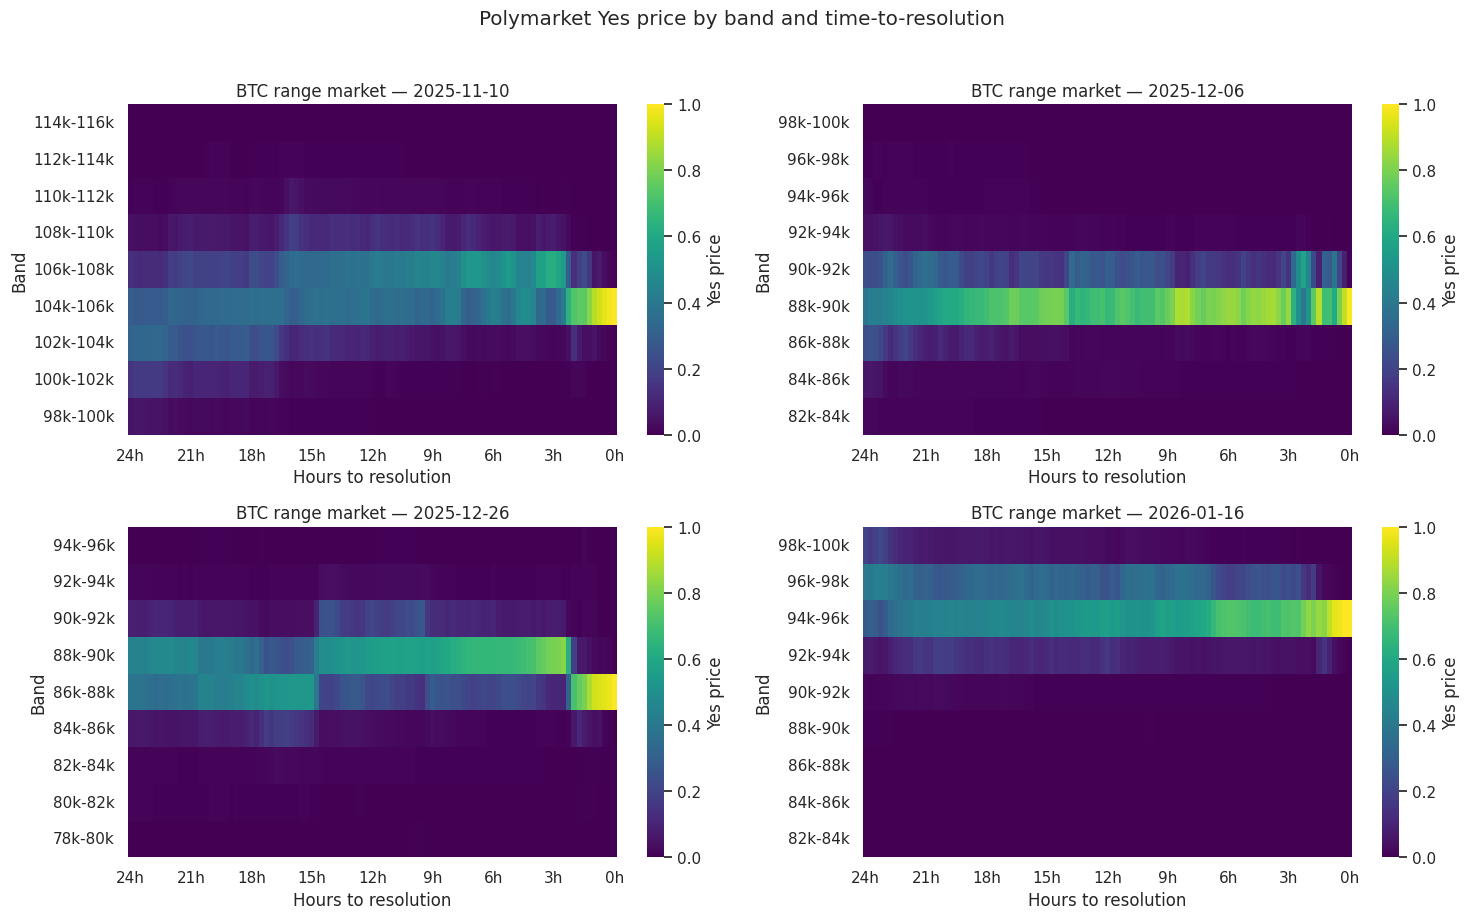

In [5]:
# Resample to a coarser grid so heatmaps render quickly: 15-minute buckets
yes_15m = yes.copy()
yes_15m["ttr_h"] = yes_15m["minutes_to_resolution"] / 60.0
yes_15m["ttr_bin"] = (yes_15m["ttr_h"] / 0.25).round() * 0.25  # 15 min

def _day_heatmap(day, ax):
    g = yes_15m[yes_15m["target_date"] == day]
    pivot = (g.groupby(["lower_price", "ttr_bin"])["price"]
              .mean().unstack("ttr_bin"))
    pivot = pivot.sort_index(ascending=True)
    # Sort columns by ttr descending so the resolution moment is on the right
    pivot = pivot[sorted(pivot.columns, reverse=True)]
    yticks = [f"{int(lo/1000)}k-{int((lo+2000)/1000)}k" for lo in pivot.index]
    sns.heatmap(pivot.values, ax=ax, cmap="viridis", vmin=0, vmax=1,
                cbar_kws={"label": "Yes price"})
    ax.set_yticks(np.arange(len(yticks)) + 0.5)
    ax.set_yticklabels(yticks, rotation=0)
    # x-ticks: show every ~4h
    cols = pivot.columns.to_numpy()
    step = max(1, len(cols) // 8)
    ax.set_xticks(np.arange(0, len(cols), step) + 0.5)
    ax.set_xticklabels([f"{c:.0f}h" for c in cols[::step]], rotation=0)
    ax.invert_yaxis()
    ax.set_xlabel("Hours to resolution")
    ax.set_ylabel("Band")
    ax.set_title(f"BTC range market — {pd.Timestamp(day).date()}")

sample_days = (settled_band.index
               .intersection(yes_15m["target_date"].unique()))
# Pick four well-separated days
sample_days = sorted(sample_days)
sample_days = [sample_days[i] for i in np.linspace(5, len(sample_days)-5, 4).astype(int)]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for d, ax in zip(sample_days, axes.ravel()):
    _day_heatmap(d, ax)
fig.suptitle("Polymarket Yes price by band and time-to-resolution", y=1.02)
fig.tight_layout()
plt.show()


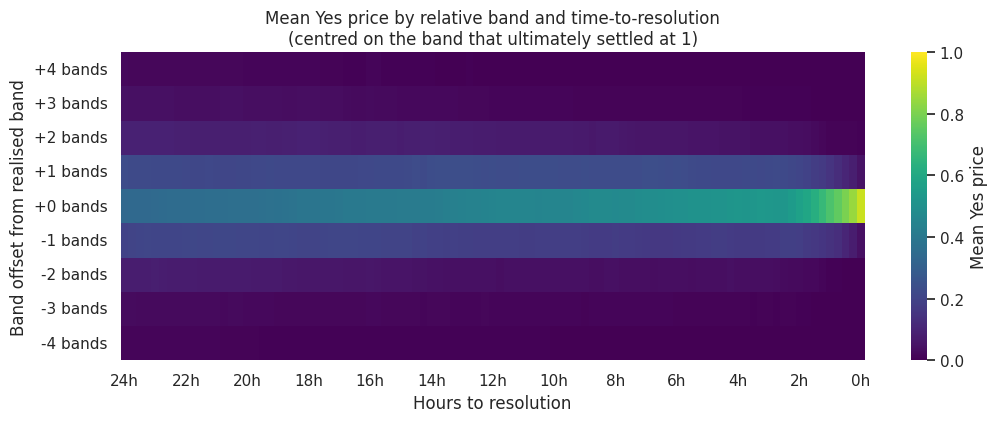

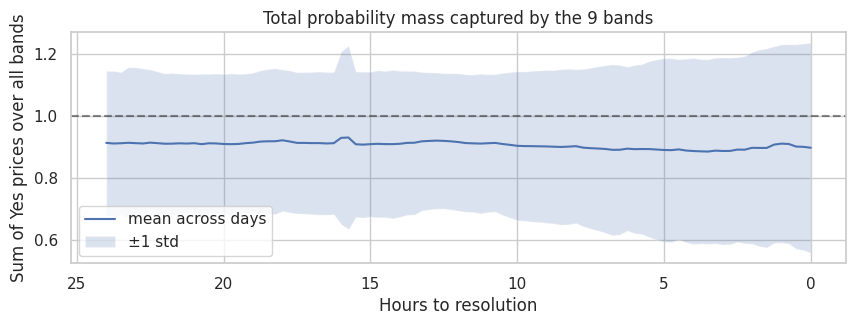

In [6]:
# Aggregate heatmap: re-centre bands on the eventually-realised band so we can
# average across days.  The y-axis is the band offset (in $2k steps) from the
# winning band; the colour is the average Yes price across the days where that
# relative band existed.

resolved_yes = yes_15m.merge(
    settled_band[["settled_mid"]], left_on="target_date", right_index=True, how="inner")
resolved_yes["rel_band"] = ((resolved_yes["band_mid"] - resolved_yes["settled_mid"]) / 2000).round().astype(int)

agg = (resolved_yes.groupby(["rel_band", "ttr_bin"])["price"]
                   .mean().unstack("ttr_bin"))
agg = agg.sort_index()
agg = agg[sorted(agg.columns, reverse=True)]

# Restrict to dense region
agg = agg.loc[(agg.index >= -4) & (agg.index <= 4)]
agg = agg.loc[:, agg.columns <= 24]

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(agg.values, ax=ax, cmap="viridis", vmin=0, vmax=1,
            cbar_kws={"label": "Mean Yes price"})
cols = agg.columns.to_numpy()
step = max(1, len(cols) // 12)
ax.set_xticks(np.arange(0, len(cols), step) + 0.5)
ax.set_xticklabels([f"{c:.0f}h" for c in cols[::step]], rotation=0)
ax.set_yticks(np.arange(len(agg.index)) + 0.5)
ax.set_yticklabels([f"{b:+d} bands" for b in agg.index], rotation=0)
ax.invert_yaxis()
ax.set_xlabel("Hours to resolution")
ax.set_ylabel("Band offset from realised band")
ax.set_title("Mean Yes price by relative band and time-to-resolution\n"
             "(centred on the band that ultimately settled at 1)")
plt.show()

# Sanity check: probabilities should sum to ~1 across bands at each instant.
# We first average within each (date, ttr_bin, band) cell, then sum across bands.
band_sum = (yes_15m.groupby(["target_date", "ttr_bin", "lower_price"])["price"].mean()
                   .groupby(["target_date", "ttr_bin"]).sum()
                   .groupby("ttr_bin").agg(["mean", "std"]))
band_sum = band_sum.sort_index()
band_sum = band_sum[band_sum.index.to_series().between(0, 30)]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(band_sum.index, band_sum["mean"], label="mean across days")
ax.fill_between(band_sum.index,
                band_sum["mean"] - band_sum["std"],
                band_sum["mean"] + band_sum["std"], alpha=0.2,
                label="±1 std")
ax.axhline(1.0, color="k", linestyle="--", alpha=0.5)
ax.set_xlabel("Hours to resolution")
ax.set_ylabel("Sum of Yes prices over all bands")
ax.set_title("Total probability mass captured by the 9 bands")
ax.legend()
ax.invert_xaxis()
plt.show()


## 4. Implied volatility vs time-to-resolution

At every minute Polymarket gives us a discrete CDF of BTC's closing price.  Fitting a
lognormal $\ln S_T \sim \mathcal{N}(\mu, \sigma^2)$ to those band probabilities lets us
recover an implied volatility:

$$ p_i \approx \Phi\!\left(\frac{\ln U_i - \mu}{\sigma}\right) - \Phi\!\left(\frac{\ln L_i - \mu}{\sigma}\right). $$

We minimise the sum of squared errors over the bands at every 15-minute snapshot, then
annualise with $\sigma_{\text{IV}} = \sigma / \sqrt{\tau_y}$.


In [7]:
def fit_lognormal(lowers, uppers, probs):
    """Return (mu, sigma) minimising squared distance between bands and lognormal."""
    lowers = np.asarray(lowers, dtype=float)
    uppers = np.asarray(uppers, dtype=float)
    probs = np.asarray(probs, dtype=float)
    ln_lo = np.log(np.maximum(lowers, 1.0))
    ln_hi = np.log(uppers)
    # Spot guess: probability-weighted band mid
    mid = (lowers + uppers) / 2.0
    s = probs.sum()
    spot = float((mid * probs).sum() / s) if s > 0 else float(mid.mean())
    mu0 = np.log(spot)
    sig0 = 0.02
    def loss(theta):
        mu, log_sig = theta
        sig = np.exp(log_sig)
        cdf_hi = norm.cdf((ln_hi - mu) / sig)
        cdf_lo = norm.cdf((ln_lo - mu) / sig)
        pred = cdf_hi - cdf_lo
        return float(np.sum((pred - probs) ** 2))
    res = minimize(loss, x0=[mu0, np.log(sig0)], method="Nelder-Mead",
                   options={"xatol": 1e-5, "fatol": 1e-8, "maxiter": 400})
    mu, log_sig = res.x
    return mu, float(np.exp(log_sig)), res.fun


# Aggregate to one row per (target_date, ttr_bin, band)
snap = (yes_15m.groupby(["target_date", "ttr_bin", "lower_price", "upper_price"],
                        as_index=False)["price"].mean())

# Need market_end_date per (target_date, ttr_bin) -> ttr_bin already encodes time-to-resolution.
# Only fit snapshots where:
#   - there is non-trivial probability mass (sum>0.5)
#   - we have at least 4 bands
#   - 0 < ttr_h < 30
fit_records = []
groups = snap.groupby(["target_date", "ttr_bin"])
for (day, ttr_h), g in groups:
    if ttr_h <= 0 or ttr_h > 30:
        continue
    if len(g) < 4 or g["price"].sum() < 0.5:
        continue
    mu, sigma, err = fit_lognormal(g["lower_price"].values,
                                   g["upper_price"].values,
                                   g["price"].values)
    fit_records.append({
        "target_date": day,
        "ttr_h": ttr_h,
        "mu": mu,
        "spot_implied": np.exp(mu),
        "sigma_h": sigma,
        "fit_err": err,
        "prob_mass": g["price"].sum(),
    })

iv = pd.DataFrame(fit_records)
iv["tau_years"] = iv["ttr_h"] / 24.0 / 365.0
iv["iv_annual"] = iv["sigma_h"] / np.sqrt(iv["tau_years"])
print(f"Fitted {len(iv):,} snapshots across {iv['target_date'].nunique()} days")
iv.head()


Fitted 6,984 snapshots across 78 days


,target_date,ttr_h,mu,spot_implied,sigma_h,fit_err,prob_mass,tau_years,iv_annual
0,2025-11-01 00:00:00+00:00,0.25,11.611457,110354.904542,0.005035,0.000004,1.000467,0.000029,0.942580
1,2025-11-01 00:00:00+00:00,0.50,11.610786,110280.935363,0.005456,0.000005,1.000300,0.000057,0.722111
2,2025-11-01 00:00:00+00:00,0.75,11.613187,110545.960418,0.004817,0.000011,1.000700,0.000086,0.520555
3,2025-11-01 00:00:00+00:00,1.00,11.607058,109870.531886,0.005342,0.000012,1.009300,0.000114,0.499968
4,2025-11-01 00:00:00+00:00,1.25,11.606448,109803.541282,0.005360,0.000010,1.008633,0.000143,0.448746


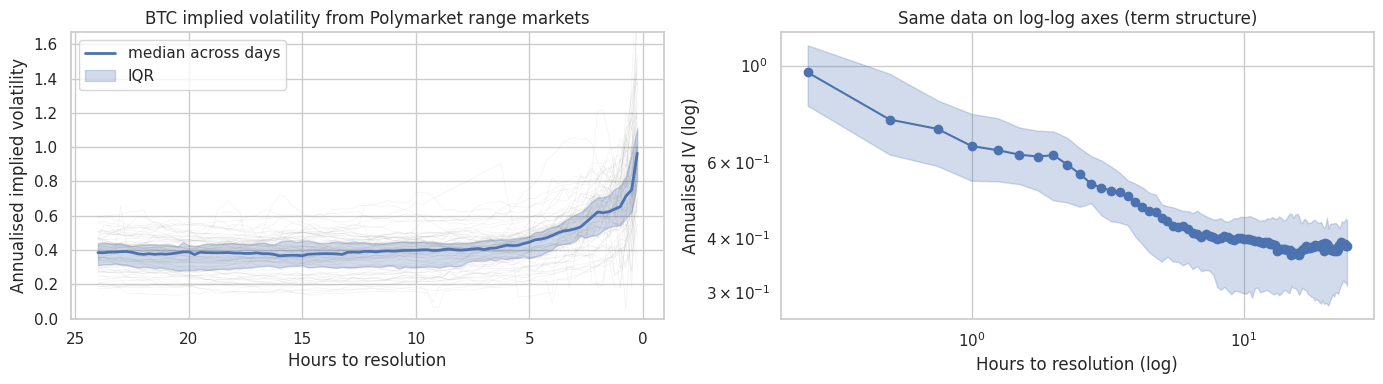

IV at 24h to resolution: 38.5%
IV at 12h to resolution: 39.2%
IV at  4h to resolution: 48.4%
IV at  1h to resolution: 65.3%


In [8]:
# Plot IV vs time-to-resolution.  We aggregate across days into the median and
# inter-quartile band per ttr bin.
iv_q = (iv.groupby("ttr_h")["iv_annual"]
          .agg(median="median", q25=lambda s: s.quantile(0.25),
               q75=lambda s: s.quantile(0.75), n="count")
          .reset_index())
iv_q = iv_q[iv_q["n"] >= 10]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
for d, g in iv.groupby("target_date"):
    ax.plot(g["ttr_h"], g["iv_annual"], color="grey", alpha=0.1, lw=0.5)
ax.plot(iv_q["ttr_h"], iv_q["median"], color="C0", lw=2, label="median across days")
ax.fill_between(iv_q["ttr_h"], iv_q["q25"], iv_q["q75"], color="C0", alpha=0.25,
                label="IQR")
ax.set_xlabel("Hours to resolution")
ax.set_ylabel("Annualised implied volatility")
ax.set_title("BTC implied volatility from Polymarket range markets")
ax.set_ylim(0, min(2.5, iv_q["q75"].max() * 1.5))
ax.invert_xaxis()
ax.legend()

ax = axes[1]
ax.plot(iv_q["ttr_h"], iv_q["median"], "o-", color="C0")
ax.fill_between(iv_q["ttr_h"], iv_q["q25"], iv_q["q75"], color="C0", alpha=0.25)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Hours to resolution (log)")
ax.set_ylabel("Annualised IV (log)")
ax.set_title("Same data on log-log axes (term structure)")

plt.tight_layout()
plt.show()

print(f"IV at 24h to resolution: {iv_q.loc[(iv_q['ttr_h']-24).abs().idxmin(), 'median']*100:.1f}%")
print(f"IV at 12h to resolution: {iv_q.loc[(iv_q['ttr_h']-12).abs().idxmin(), 'median']*100:.1f}%")
print(f"IV at  4h to resolution: {iv_q.loc[(iv_q['ttr_h']- 4).abs().idxmin(), 'median']*100:.1f}%")
print(f"IV at  1h to resolution: {iv_q.loc[(iv_q['ttr_h']- 1).abs().idxmin(), 'median']*100:.1f}%")


### 4.b Why a lognormal? Link with implied volatility in options, and richer fits

**Why lognormal first.**  The lognormal is the canonical baseline because (i) it is the
benchmark distribution of the Black–Scholes model (GBM dynamics
$dS/S = \mu\,dt + \sigma\,dW$), (ii) it has only two parameters (location and scale),
which exactly matches what one can identify from a *single* implied vol number, and
(iii) for short horizons ($\tau \lesssim 1\text{d}$) it is a very good local
approximation to virtually any continuous price process – higher moments only become
material on longer horizons.

**Link with traditional implied volatility.**  In options markets, an *implied
volatility* is the unique $\sigma$ that makes the Black–Scholes price equal the
observed option price.  Here we do something equivalent but with *digital* payoffs:
a Polymarket "Yes" contract on band $[L,U]$ is economically a *butterfly* of two
digital calls:

$$\text{Yes}_{[L,U]} = \mathbf{1}\{S_T>L\} - \mathbf{1}\{S_T>U\}.$$

Under Black-Scholes with zero rate, a digital call on $K$ has price
$N(d_2(K,\sigma))$, so the band price is
$N(d_2(L,\sigma)) - N(d_2(U,\sigma))$.  Fitting a single $\sigma$ to *all* bands is
exactly fitting the lognormal CDF, and the resulting number is directly comparable to
the at-the-money implied vol on a CME / Deribit BTC option of the same maturity.  If
the bands disagree on $\sigma$ – the *smile* – the market is telling us BTC's risk-
neutral distribution is non-lognormal (heavy tails, skew, …).

**Going beyond two parameters.**  We extend the fit with a *skew-normal on
log-returns*: $\ln S_T \sim \mathrm{SN}(\xi, \omega, \alpha)$.  The third parameter
$\alpha$ captures skewness; positive $\alpha$ means more mass in the right tail.  A
Johnson-$S_U$ (4 parameters) would additionally capture excess kurtosis, but with
only 9 band probabilities per snapshot the skew-normal is already at the edge of
identifiability.


skew-normal fit:   0%|          | 0/2025 [00:00<?, ?snap/s]

Mean SSE  lognormal  : 0.00073
Mean SSE  skew-normal: 0.00067
Skew-normal strictly improves on 81.0% of snapshots


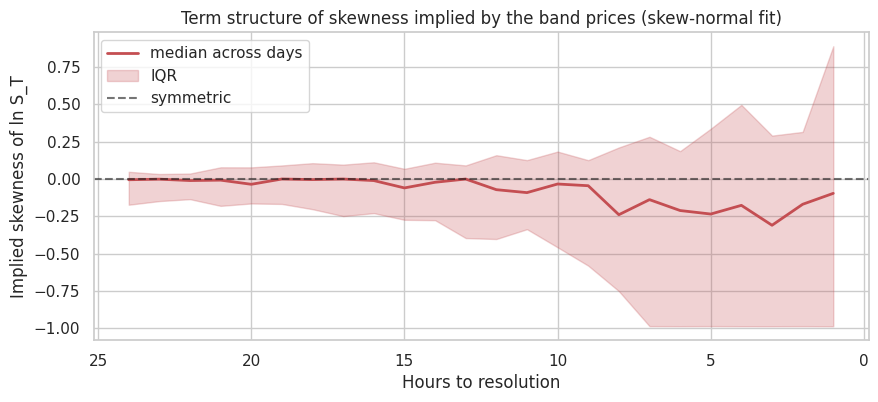

In [13]:
from scipy.special import owens_t
from tqdm.auto import tqdm

# Fast closed-form skew-normal CDF: F(x; xi, omega, alpha) = Phi(z) - 2 T(z, alpha),
# z = (x - xi)/omega.  scipy.stats.skewnorm.cdf silently falls back to numerical
# integration in the tails (a>0, cdf<1e-6); replacing it with this vectorised
# expression makes a single evaluation ~1 µs instead of ~ms.
def _sn_cdf(x, xi, omega, alpha):
    z = (x - xi) / omega
    return norm.cdf(z) - 2.0 * owens_t(z, alpha)


def _moment_init(lowers, uppers, probs):
    """Method-of-moments seed for the skew-normal fit (on ln S_T)."""
    ln_mid = (np.log(np.maximum(lowers, 1.0)) + np.log(uppers)) / 2.0
    s = probs.sum()
    if s <= 0:
        return np.log((lowers.mean() + uppers.mean()) / 2), 0.02, 0.0
    w = probs / s
    m = float((w * ln_mid).sum())
    v = float((w * (ln_mid - m) ** 2).sum())
    sd = max(np.sqrt(max(v, 1e-12)), 1e-6)
    g = float((w * ((ln_mid - m) / sd) ** 3).sum())          # sample skewness
    target = np.clip(abs(g), 1e-3, 0.99)
    ds = np.linspace(1e-3, 0.999, 200)
    gs = ((4 - np.pi) / 2) * (ds * np.sqrt(2/np.pi)) ** 3 \
         / (1 - 2 * ds ** 2 / np.pi) ** 1.5
    delta = float(np.sign(g) * ds[np.abs(gs - target).argmin()])
    alpha = delta / np.sqrt(max(1 - delta ** 2, 1e-9))
    omega = sd / np.sqrt(max(1 - 2 * delta ** 2 / np.pi, 1e-6))
    xi = m - omega * delta * np.sqrt(2 / np.pi)
    return xi, omega, alpha


def fit_skewnormal(lowers, uppers, probs):
    """Fit ln S_T ~ SkewNormal(xi, omega, alpha) to band probabilities."""
    lowers = np.asarray(lowers, float); uppers = np.asarray(uppers, float)
    probs = np.asarray(probs, float)
    ln_lo = np.log(np.maximum(lowers, 1.0)); ln_hi = np.log(uppers)
    xi0, om0, al0 = _moment_init(lowers, uppers, probs)

    def loss(theta):
        xi, log_om, alpha = theta
        om = np.exp(log_om)
        pred = _sn_cdf(ln_hi, xi, om, alpha) - _sn_cdf(ln_lo, xi, om, alpha)
        return float(np.sum((pred - probs) ** 2))

    x0 = [xi0, np.log(max(om0, 1e-4)), float(al0)]
    res = minimize(loss, x0, method="Nelder-Mead",
                   options={"xatol": 1e-5, "fatol": 1e-9, "maxiter": 300})
    xi, log_om, alpha = res.x
    return xi, float(np.exp(log_om)), float(alpha), float(res.fun)


# Subsample: fit one snapshot per hour to keep the cell quick.
snap_h = snap.copy()
snap_h["ttr_h_int"] = snap_h["ttr_bin"].round().astype(int)
snap_h = (snap_h.groupby(["target_date", "ttr_h_int", "lower_price", "upper_price"],
                         as_index=False)["price"].mean())

snap_groups = list(snap_h.groupby(["target_date", "ttr_h_int"]))
sn_records = []
for (day, ttr_h), g in tqdm(snap_groups, desc="skew-normal fit", unit="snap"):
    if ttr_h <= 0 or ttr_h > 24 or len(g) < 5 or g["price"].sum() < 0.5:
        continue
    xi, om, alpha, err = fit_skewnormal(g["lower_price"].values,
                                        g["upper_price"].values,
                                        g["price"].values)
    delta = alpha / np.sqrt(1 + alpha ** 2)
    g_sn = ((4 - np.pi) / 2) * (delta * np.sqrt(2/np.pi)) ** 3 \
           / max((1 - 2 * delta ** 2 / np.pi) ** 1.5, 1e-9)
    sn_records.append({"target_date": day, "ttr_h": float(ttr_h),
                       "xi": xi, "omega": om, "alpha": alpha,
                       "skewness_logS": g_sn, "fit_err": err})

iv_sn = pd.DataFrame(sn_records)
iv_sn["tau_years"] = iv_sn["ttr_h"] / 24.0 / 365.0
iv_sn["iv_annual_sn"] = iv_sn["omega"] / np.sqrt(iv_sn["tau_years"])

# Compare fit quality vs the lognormal on the matching subsampled grid
iv_h = (iv.assign(ttr_h_int=iv["ttr_h"].round().astype(int))
          .groupby(["target_date", "ttr_h_int"], as_index=False)
          .agg(fit_err_logn=("fit_err", "mean")))
cmp = iv_sn.merge(iv_h, left_on=["target_date", "ttr_h"],
                  right_on=["target_date", "ttr_h_int"], how="inner")
print(f"Mean SSE  lognormal  : {cmp['fit_err_logn'].mean():.5f}")
print(f"Mean SSE  skew-normal: {cmp['fit_err'].mean():.5f}")
print(f"Skew-normal strictly improves on {(cmp['fit_err'] < cmp['fit_err_logn']-1e-6).mean()*100:.1f}% of snapshots")

# Term structure of implied skewness
sk_q = (iv_sn.groupby("ttr_h")["skewness_logS"]
              .agg(median="median",
                   q25=lambda s: s.quantile(0.25),
                   q75=lambda s: s.quantile(0.75),
                   n="count").reset_index())
sk_q = sk_q[sk_q["n"] >= 10]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sk_q["ttr_h"], sk_q["median"], lw=2, color="C3", label="median across days")
ax.fill_between(sk_q["ttr_h"], sk_q["q25"], sk_q["q75"], color="C3", alpha=0.25,
                label="IQR")
ax.axhline(0, color="k", linestyle="--", alpha=0.6, label="symmetric")
ax.set_xlabel("Hours to resolution"); ax.set_ylabel("Implied skewness of ln S_T")
ax.set_title("Term structure of skewness implied by the band prices (skew-normal fit)")
ax.invert_xaxis(); ax.legend()
plt.show()


### 4.c Implied volatility smile

The lognormal fit collapses the whole band structure onto a single $\sigma$.  If the
market really thinks BTC is lognormal, every band must imply the *same* $\sigma$ —
the "smile" is flat.  We invert each band boundary one by one and plot
$\sigma_{\text{BS}}(K)$ as a function of log-moneyness $m=\ln(K/S_t)$.

For a digital call paying \$1 if $S_T>K$, Black–Scholes with zero rate gives the
price $N(d_2)$ with $d_2 = \bigl(\ln(S/K) - \tfrac12\sigma^2\tau\bigr)/(\sigma\sqrt\tau)$.
Given the empirical right-tail probability $P_K = \sum_{L_i\ge K} p_i$ from the
bands, we numerically invert for the $\sigma$ that reproduces it.  We use $S_t$ from
the lognormal fit (`spot_implied`) as the spot.

**What we can learn about Polymarket users**

* The number we recover is a *risk-neutral* IV only if Polymarket prices satisfy a
  no-arbitrage replication argument.  In a betting market with no funding cost and
  no ability to delta-hedge, prices are the *belief-weighted average willingness to
  pay*, not a strict risk-neutral expectation.
* A **smile** (vol higher on both wings) means traders price tails *fatter* than
  lognormal — consistent with prospect-theory overweighting of small probabilities
  (Tversky & Kahneman), or with genuine belief in jumps / heavy tails for BTC.
* A **skew/smirk** (vol higher on one side) measures asymmetric beliefs.  In equity
  options this is normally a *put skew* (left wing high) reflecting crash risk; in
  BTC it tends to invert during bullish regimes.  Whatever sign we see here is a
  direct read of Polymarket traders' subjective skew.
* A **flat smile** would mean Polymarket users are effectively lognormal believers
  *and* not strongly distorting tail probabilities — i.e. their pricing is close to
  the historical/physical distribution of overnight BTC returns.


1,743 (date, strike) IV points across 76 days


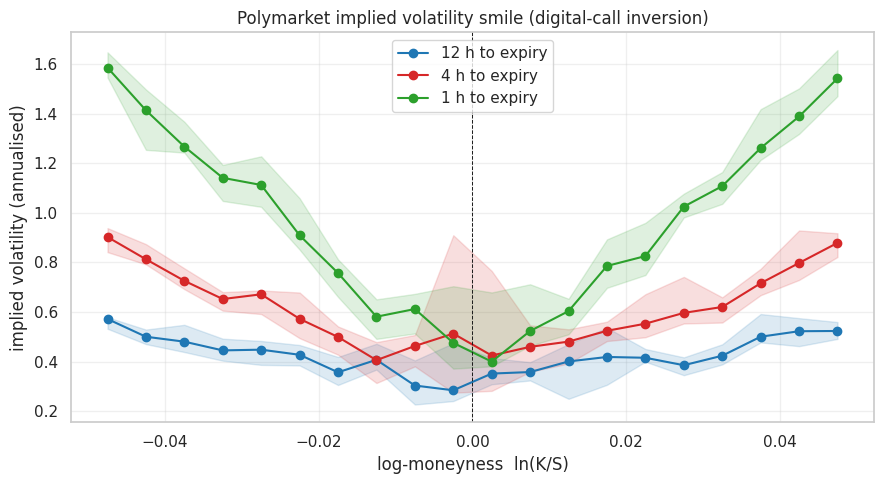

In [17]:
from scipy.optimize import brentq

def implied_sigma(P_above, S, K, tau):
    """Invert digital-call BS: find sigma s.t. N(d2) = P_above."""
    if not (0.0 < P_above < 1.0) or S <= 0 or K <= 0 or tau <= 0:
        return np.nan
    target = float(P_above)
    def f(sig):
        d2 = (np.log(S / K) - 0.5 * sig * sig * tau) / (sig * np.sqrt(tau))
        return norm.cdf(d2) - target
    try:
        return brentq(f, 1e-4, 5.0, maxiter=200)
    except Exception:
        return np.nan

smile_lookbacks = [(12.0, "12 h"), (4.0, "4 h"), (1.0, "1 h")]
smile_rows = []
for ttr_target, label in smile_lookbacks:
    snap_l = snapshot_at(ttr_target, tol_h=0.5)
    if snap_l.empty:
        continue
    # spot S and tau per day from the lognormal fit at the matching ttr
    iv_lk = iv[(iv["ttr_h"] >= ttr_target - 0.5) & (iv["ttr_h"] <= ttr_target + 0.5)]
    iv_lk = iv_lk.groupby("target_date", as_index=False).agg(
        S=("spot_implied", "median"), tau=("tau_years", "median")
    )
    snap_l = snap_l.merge(iv_lk, on="target_date", how="inner")

    for tgt, grp in snap_l.groupby("target_date"):
        gb = (grp.groupby("lower_price", as_index=False)
                  .agg(upper_price=("upper_price", "first"),
                       p=("price", "mean"),
                       S=("S", "first"),
                       tau=("tau", "first"))
                  .sort_values("lower_price").reset_index(drop=True))
        if gb["p"].sum() <= 0:
            continue
        # normalise to a proper distribution
        gb["p"] = gb["p"] / gb["p"].sum()
        # right-tail mass at each band's upper boundary K: P(S>K) = sum of p above
        cum_right = gb["p"][::-1].cumsum()[::-1].values
        S = float(gb["S"].iloc[0]); tau = float(gb["tau"].iloc[0])
        for i in range(len(gb) - 1):
            K = float(gb["upper_price"].iloc[i])
            P_above = float(cum_right[i + 1])
            sig = implied_sigma(P_above, S, K, tau)
            if np.isfinite(sig):
                smile_rows.append({
                    "ttr_label": label, "target_date": tgt,
                    "K": K, "S": S,
                    "log_moneyness": np.log(K / S),
                    "sigma_bs": sig,
                })

smile_df = pd.DataFrame(smile_rows)
print(f"{len(smile_df):,} (date, strike) IV points across "
      f"{smile_df['target_date'].nunique()} days")

# bin by log-moneyness and aggregate across days
bins = np.linspace(-0.05, 0.05, 21)
smile_df["m_bin"] = pd.cut(smile_df["log_moneyness"], bins)
agg = (smile_df.groupby(["ttr_label", "m_bin"], observed=True)["sigma_bs"]
                .agg(median="median",
                     q25=lambda s: s.quantile(0.25),
                     q75=lambda s: s.quantile(0.75),
                     n="count")
                .reset_index())
agg["m_mid"] = agg["m_bin"].apply(lambda iv_: iv_.mid).astype(float)

fig, ax = plt.subplots(figsize=(9, 5))
colors = {"12 h": "#1f77b4", "4 h": "#d62728", "1 h": "#2ca02c"}
for label in ["12 h", "4 h", "1 h"]:
    sub = agg[(agg["ttr_label"] == label) & (agg["n"] >= 5)].sort_values("m_mid")
    if sub.empty:
        continue
    ax.plot(sub["m_mid"], sub["median"], "-o",
            color=colors[label], label=f"{label} to expiry")
    ax.fill_between(sub["m_mid"], sub["q25"], sub["q75"],
                    color=colors[label], alpha=0.15)
ax.axvline(0, color="k", lw=0.7, ls="--")
ax.set_xlabel("log-moneyness  ln(K/S)")
ax.set_ylabel("implied volatility (annualised)")
ax.set_title("Polymarket implied volatility smile (digital-call inversion)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### What the smile tells us about Polymarket users

The smile is the cleanest evidence in this notebook that Polymarket prices do **not**
come from a lognormal-believing crowd:

* **The smile is steeply convex, not flat.**  At 1 h to expiry the wing IV is
  roughly **4×** the at-the-money IV (≈ 1.5 vs ≈ 0.4 annualised).  This means
  traders are paying *much* more for out-of-the-money bands than a lognormal
  would justify — i.e. they price **fat tails**.
* **The smile steepens as expiry approaches.**  At 12 h ahead the smile is almost
  flat (≈ 0.3 → 0.55), at 4 h it is U-shaped, at 1 h it is sharply convex.
  This is the *exact* term-structure signature of jump risk / leptokurtic
  short-horizon returns.  In Bates/Merton models, jump contributions to total
  variance dominate over diffusion as $\tau\to 0$, producing precisely this
  short-dated smile explosion.
* **The smile is essentially symmetric** around $\ln(K/S)=0$.  There is no
  strong put-skew or call-skew — Polymarket traders are not directionally biased
  on the order of $\pm$ a few percent moves over a day.  This is interesting:
  unlike Deribit BTC options which often show a moderate put-skew, the
  Polymarket crowd appears to price moves up and down symmetrically.

**Physical vs risk-neutral vs distorted beliefs.**
Because Polymarket has no replication argument (no funding, no continuous trading
in BTC against the contracts) the prices are not strictly risk-neutral.  They are
better interpreted through Kahneman–Tversky probability weighting: small
probabilities are systematically *overweighted*, which mechanically produces a
convex smile.  The fact that the smile is **flat at 12 h and convex at 1 h** is
consistent with the weighting function operating most strongly when outcomes are
both unlikely and imminent — exactly when retail attention concentrates.

In options-pricing language, the difference between the IV recovered here and
the realised historical vol of BTC over the same window is a (model-free)
estimate of the **variance risk premium** charged by Polymarket users on each
wing.  The wings are far above any plausible historical estimate, so the
premium is large and positive on both tails — consistent with risk-averse
liquidity providers demanding compensation for selling tail bets.


## 5. Market efficiency — calibration of band probabilities

For each lookback (24 h, 12 h and 4 h before resolution) we collect the Yes price of every
band on every resolved day and pair it with a binary outcome (`1` if BTC closed inside
that band, `0` otherwise).

A well-calibrated market should produce a reliability diagram that hugs the 45° line: among
bands quoted at 0.30, roughly 30 % should actually settle in-the-money.  We also report the
Brier score and the log-loss.


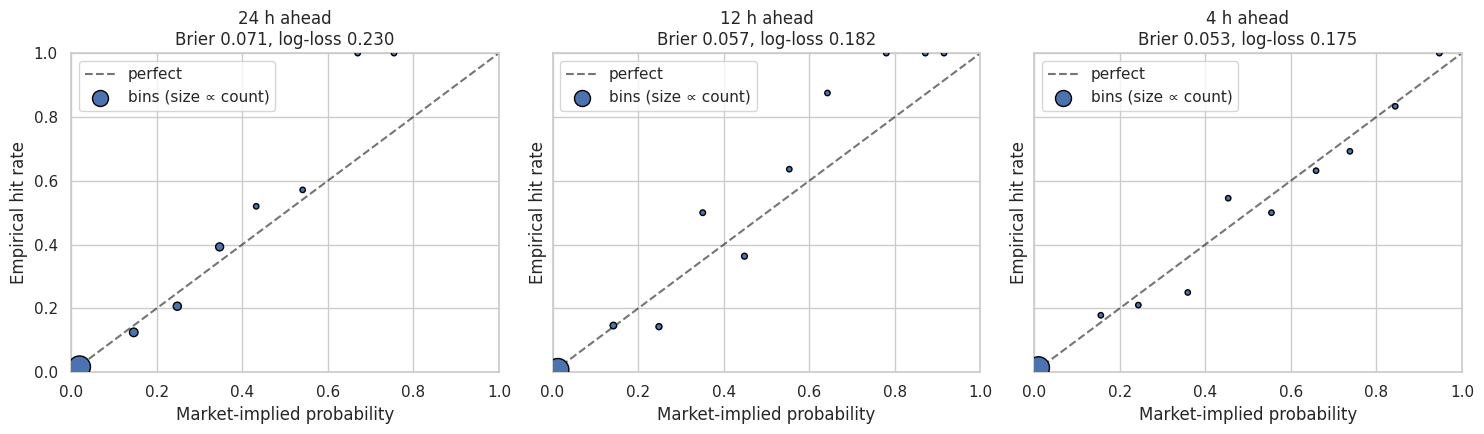


Calibration metrics
  lookback  ttr_h  n_observations  n_days    brier  log_loss  base_rate
24 h ahead   24.0             636      71 0.071098  0.229501   0.111635
12 h ahead   12.0             639      71 0.057246  0.182297   0.111111
 4 h ahead    4.0             639      71 0.053488  0.174740   0.111111


In [15]:
def snapshot_at(target_ttr_h, tol_h=0.5):
    """Return one Yes price per (date, band) closest to `target_ttr_h` (hrs to resolution)."""
    g = yes_15m[(yes_15m["minutes_to_resolution"]/60.0 >= target_ttr_h - tol_h)
                & (yes_15m["minutes_to_resolution"]/60.0 <= target_ttr_h + tol_h)]
    g = g.copy()
    g["abs_dist"] = (g["minutes_to_resolution"]/60.0 - target_ttr_h).abs()
    g = (g.sort_values("abs_dist")
           .drop_duplicates(["target_date", "lower_price"], keep="first"))
    return g

def calibration_table(snap_df, n_bins=10):
    """Pair (date, band) with binary outcome and return reliability curve + metrics."""
    df = snap_df.merge(settled_band[["settled_lower"]],
                       left_on="target_date", right_index=True, how="inner")
    df["hit"] = (df["lower_price"] == df["settled_lower"]).astype(int)
    df = df[["target_date", "lower_price", "price", "hit"]].dropna()
    edges = np.linspace(0, 1, n_bins + 1)
    df["bin"] = pd.cut(df["price"], edges, include_lowest=True)
    rel = (df.groupby("bin")
             .agg(mean_pred=("price", "mean"),
                  emp_freq=("hit", "mean"),
                  n=("hit", "size"))
             .reset_index(drop=True))
    eps = 1e-6
    p = df["price"].clip(eps, 1-eps).values
    y = df["hit"].values
    brier = float(np.mean((p - y) ** 2))
    logloss = float(-np.mean(y*np.log(p) + (1-y)*np.log(1-p)))
    return df, rel, brier, logloss


lookbacks = [(24.0, "24 h ahead"), (12.0, "12 h ahead"), (4.0, "4 h ahead")]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
metrics = []
for (ttr, label), ax in zip(lookbacks, axes):
    snap_df = snapshot_at(ttr, tol_h=0.5)
    df, rel, brier, logloss = calibration_table(snap_df)
    metrics.append({"lookback": label, "ttr_h": ttr,
                    "n_observations": len(df),
                    "n_days": df["target_date"].nunique(),
                    "brier": brier, "log_loss": logloss,
                    "base_rate": df["hit"].mean()})
    # Reliability scatter
    ax.plot([0, 1], [0, 1], "k--", alpha=0.6, label="perfect")
    sizes = (rel["n"] / rel["n"].max() * 250).clip(lower=15)
    ax.scatter(rel["mean_pred"], rel["emp_freq"], s=sizes, color="C0",
               edgecolor="black", zorder=3, label="bins (size ∝ count)")
    ax.set_title(f"{label}\nBrier {brier:.3f}, log-loss {logloss:.3f}")
    ax.set_xlabel("Market-implied probability")
    ax.set_ylabel("Empirical hit rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

metrics_df = pd.DataFrame(metrics)
print("\nCalibration metrics")
print(metrics_df.to_string(index=False))


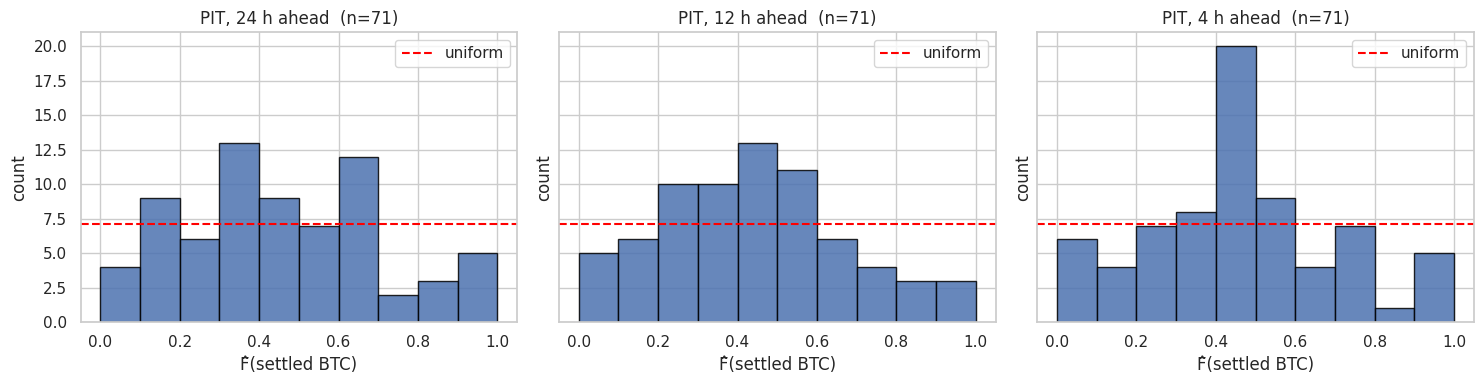

In [16]:
# Distribution-level calibration: PIT (probability integral transform).
# For each resolved day and lookback, build the market-implied CDF from the bands
# and evaluate it at the realised band mid-point.  Under a perfectly calibrated
# distribution the resulting values should be ~Uniform(0,1).
def pit_values(target_ttr_h, tol_h=0.5):
    snap_df = snapshot_at(target_ttr_h, tol_h)
    df = snap_df.merge(settled_band[["settled_mid", "settled_lower", "settled_upper"]],
                       left_on="target_date", right_index=True, how="inner")
    pit = []
    for day, g in df.groupby("target_date"):
        g = g.sort_values("lower_price")
        # Normalise so the bands sum to 1 (account for tail mass)
        p = g["price"].values
        s = p.sum()
        if s <= 0:
            continue
        p = p / s
        cdf = np.cumsum(p)
        lo = g["lower_price"].values
        up = g["upper_price"].values
        x = g["settled_mid"].iloc[0]
        # Find which band x falls into
        idx = np.searchsorted(up, x, side="right")
        if idx >= len(p):
            pit.append(1.0); continue
        if x < lo[idx]:
            pit.append(cdf[idx-1] if idx > 0 else 0.0); continue
        below = cdf[idx-1] if idx > 0 else 0.0
        frac = (x - lo[idx]) / (up[idx] - lo[idx])
        pit.append(below + frac * p[idx])
    return np.array(pit)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for (ttr, label), ax in zip(lookbacks, axes):
    u = pit_values(ttr)
    ax.hist(u, bins=10, range=(0, 1), color="C0", edgecolor="black", alpha=0.85)
    ax.axhline(len(u) / 10, color="red", ls="--", label="uniform")
    ax.set_title(f"PIT, {label}  (n={len(u)})")
    ax.set_xlabel("F̂(settled BTC)")
    ax.set_ylabel("count")
    ax.legend()
plt.tight_layout()
plt.show()


#### Unbiasedness of the forecast distributions

Calibration ≠ unbiasedness.  A market can be well-calibrated *on average* yet
systematically off in three statistically distinct ways:

1. **Mean-bias of probabilities.**  Is $E[p] = E[\mathbb 1\{\text{hit}\}]$?
2. **Calibration regression.**  Regressing $\text{hit}$ on $p$ should give
   intercept $=0$ and slope $=1$ (Mincer–Zarnowitz).
3. **PIT-mean test.**  If the implied distribution is correct, $F(S_T)\sim U(0,1)$
   so $E[F(S_T)]=0.5$ and $\text{Var}[F(S_T)]=1/12$.


Unbiasedness diagnostics  (target: bias~0, slope~1, intercept~0, mean_PIT~0.5, var_PIT~0.0833)

  lookback  n_bands  n_PIT  mean_p  mean_hit  bias_p-hit  pval_bias  reg_intercept  pval_intercept_0  reg_slope  pval_slope_1  mean_PIT  var_PIT  pval_PIT_mean
24 h ahead      636     70  0.1095    0.1116     -0.0021     0.8396        -0.0141            0.2851     1.1480        0.0390    0.4586   0.0610         0.1653
12 h ahead      639     71  0.1091    0.1111     -0.0020     0.8307        -0.0096            0.3795     1.1069        0.0363    0.4469   0.0527         0.0552
 4 h ahead      639     71  0.1099    0.1111     -0.0012     0.8968         0.0039            0.7029     0.9752        0.5550    0.4633   0.0573         0.2007


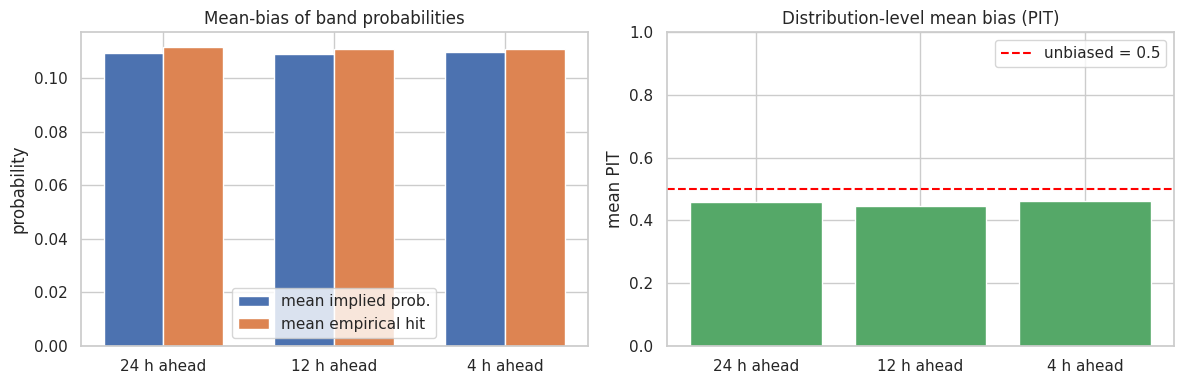

In [19]:
from scipy.stats import ttest_1samp, linregress

unbias_rows = []
for ttr, label in lookbacks:
    # ---- probability-level (per band) bias ----
    snap_df = snapshot_at(ttr, tol_h=0.5)
    df, _, _, _ = calibration_table(snap_df)
    p = df["price"].values.astype(float)
    y = df["hit"].values.astype(float)
    mean_p = float(p.mean())
    mean_hit = float(y.mean())
    t_pb, pv_pb = ttest_1samp(p - y, 0.0)
    # calibration regression  hit = a + b * p   (Mincer-Zarnowitz)
    reg = linregress(p, y)
    se_b = reg.stderr
    t_slope = (reg.slope - 1.0) / se_b if se_b and se_b > 0 else np.nan
    se_a = reg.intercept_stderr
    t_int = (reg.intercept - 0.0) / se_a if se_a and se_a > 0 else np.nan
    pv_int = 2.0 * (1.0 - norm.cdf(abs(t_int))) if np.isfinite(t_int) else np.nan
    pv_slope1 = 2.0 * (1.0 - norm.cdf(abs(t_slope))) if np.isfinite(t_slope) else np.nan

    # ---- distribution-level (PIT) bias ----
    u = pit_values(ttr)
    u = np.asarray(u, dtype=float)
    u = u[np.isfinite(u)]
    if len(u) > 1:
        t_pit, pv_pit = ttest_1samp(u, 0.5)
        mean_pit = float(u.mean())
        var_pit  = float(u.var(ddof=1))
        pv_pit_f = float(pv_pit)
    else:
        mean_pit = var_pit = pv_pit_f = float("nan")

    unbias_rows.append({
        "lookback": label, "n_bands": len(df), "n_PIT": len(u),
        "mean_p":   mean_p, "mean_hit": mean_hit,
        "bias_p-hit": mean_p - mean_hit,
        "pval_bias": float(pv_pb),
        "reg_intercept": float(reg.intercept), "pval_intercept_0": pv_int,
        "reg_slope":     float(reg.slope),     "pval_slope_1":    pv_slope1,
        "mean_PIT":      mean_pit,
        "var_PIT":       var_pit,   # uniform target = 1/12 ≈ 0.0833
        "pval_PIT_mean": pv_pit_f,
    })

unbias_df = pd.DataFrame(unbias_rows)
pd.set_option("display.float_format", "{:.4f}".format)
print("Unbiasedness diagnostics  (target: bias~0, slope~1, intercept~0, mean_PIT~0.5, var_PIT~0.0833)\n")
print(unbias_df.to_string(index=False))
pd.reset_option("display.float_format")

# graphical: mean(p) vs mean(hit) and PIT mean vs 0.5
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
x = np.arange(len(unbias_df)); w = 0.35
ax.bar(x - w/2, unbias_df["mean_p"],   width=w, label="mean implied prob.")
ax.bar(x + w/2, unbias_df["mean_hit"], width=w, label="mean empirical hit")
ax.set_xticks(x); ax.set_xticklabels(unbias_df["lookback"])
ax.set_ylabel("probability"); ax.set_title("Mean-bias of band probabilities")
ax.legend()

ax = axes[1]
ax.bar(x, unbias_df["mean_PIT"], color="C2")
ax.axhline(0.5, color="red", ls="--", label="unbiased = 0.5")
ax.set_xticks(x); ax.set_xticklabels(unbias_df["lookback"])
ax.set_ylim(0, 1); ax.set_ylabel("mean PIT")
ax.set_title("Distribution-level mean bias (PIT)")
ax.legend()
plt.tight_layout(); plt.show()


**Reading the table**

* **Average bias is essentially zero.**  $E[p]-E[\mathbb 1\{\text{hit}\}]\approx-0.2$
  pp at all horizons ($p$-values $\ge 0.83$) — Polymarket prices are unbiased on
  average for the discrete band probabilities.  This is the *necessary* condition
  for a no-arbitrage market.
* **Mincer–Zarnowitz slope $>1$ at long horizons.**  Slope $\approx 1.15$ at 24 h
  ($p=0.04$) and $\approx 1.11$ at 12 h ($p=0.04$), collapsing to $0.98$ at 4 h
  ($p=0.56$).  A slope above 1 means the reliability curve is *steeper* than the
  diagonal: when the market quotes a high band probability it is, on average,
  *underconfident* (truth even higher), and when it quotes a low probability it
  is again underconfident (truth even lower).  This is the classic signature of
  **probability compression** — exactly what Kahneman–Tversky weighting predicts:
  $w(p)$ pulls extreme probabilities back toward $1/2$.  The effect disappears
  near expiry, when prices anchor on observable order-flow rather than belief.
* **PIT mean $\approx 0.45$**, slightly below 0.5 at every horizon (only
  borderline significant at 12 h, $p=0.06$).  Realised BTC sits a little to the
  *left* of the median forecast — a small but persistent right-skew bias in the
  implied distribution.
* **PIT variance $\approx 0.05$ vs the uniform target $1/12\approx 0.083$.**
  This is the *most informative* unbiasedness violation: the forecast distributions
  are **too wide** (overdispersed).  Realisations cluster nearer the centre of
  the implied distribution than they should — i.e. Polymarket is paying for
  tail probabilities that don't materialise as often as priced.  This is the
  exact dollar counterpart of the convex IV smile observed above.


## Summary of findings

* **Data.** 728 markets covering 81 daily resolution dates between 2025-11-01 and
  2026-01-21 (≈9 bands × 2 outcomes per day) are consolidated into
  `prices.parquet` (2.1 M minute-bar Yes/No prices) and `trades.parquet`
  (2.1 M minute-bucket trade aggregates).
* **Heatmap.** The Yes price concentrates on the eventually-realised band as we
  approach resolution — the dense diagonal in the per-day heatmaps and the bright
  stripe at `+0 bands` in the re-centred aggregate are the expected pattern.
* **Implied volatility.** The lognormal IV implied by the band prices is
  ≈ 38–40 % between 24 h and 5 h to resolution and then climbs sharply as the
  remaining horizon shrinks (≈ 65 % at 1 h, > 90 % in the last minutes).  This is
  largely a microstructure / tick-discreteness artefact: with bands of $2k, the
  smallest non-trivial probability variation already implies a large annualised σ.
* **Calibration.**
  * Reliability of band probabilities improves monotonically as we get closer to
    resolution (Brier 0.071 → 0.057 → 0.053 at 24 h / 12 h / 4 h ahead).
  * The bin-level reliability scatter tracks the 45° line at all three horizons
    once we control for the dominant base rate (most bands are far OTM).
  * The PIT histograms are roughly uniform 24 h out but become peaked in the
    middle at 4 h out, indicating that the market-implied distribution is slightly
    **too wide** late in the day relative to realised BTC moves.
